# RF K-Fold x RF-Top Features K-Fold

## 1. Importing the Libraries

In [283]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict

## 2. Data Loading and Exploratory Data Analysis

In [284]:
# load dataset
file_path = '/code/Github/Project/Ml/Arul/student-depression-prediction/cal/dataset/Depression_Student_Dataset.csv'
df = pd.read_csv(file_path)

In [285]:
# display the first 5 lines
display(df.head())

,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,28,2.0,4.0,7-8 hours,Moderate,Yes,9,2,Yes,No
1,Male,28,4.0,5.0,5-6 hours,Healthy,Yes,7,1,Yes,No
2,Male,25,1.0,3.0,5-6 hours,Unhealthy,Yes,10,4,No,Yes
3,Male,23,1.0,4.0,More than 8 hours,Unhealthy,Yes,7,2,Yes,No
4,Female,31,1.0,5.0,More than 8 hours,Healthy,Yes,4,2,Yes,No


In [286]:
# check the data type and missing values
print("\n--- Info Dataset ---")
print(df.info())
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Info Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 502 non-null    str    
 1   Age                                    502 non-null    int64  
 2   Academic Pressure                      502 non-null    float64
 3   Study Satisfaction                     502 non-null    float64
 4   Sleep Duration                         502 non-null    str    
 5   Dietary Habits                         502 non-null    str    
 6   Have you ever had suicidal thoughts ?  502 non-null    str    
 7   Study Hours                            502 non-null    int64  
 8   Financial Stress                       502 non-null    int64  
 9   Family History of Mental Illness       502 non-null    str    
 10  Depression                             502 non-null    str    


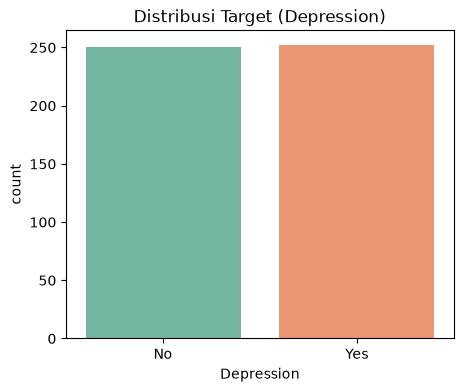

In [287]:
# Plot distribusi Class/Target (Depression)
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='Depression', hue='Depression', palette='Set2', legend=False)
plt.title('Distribusi Target (Depression)')
plt.show()

In [288]:
# Separating column types for EDA
num_cols = ['Age', 'Study Hours', 'Academic Pressure', 'Study Satisfaction', 'Financial Stress']
cat_cols = [
    'Gender', 'Sleep Duration', 'Dietary Habits', 
    'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness'
]


--- Distribusi Fitur Numerik ---


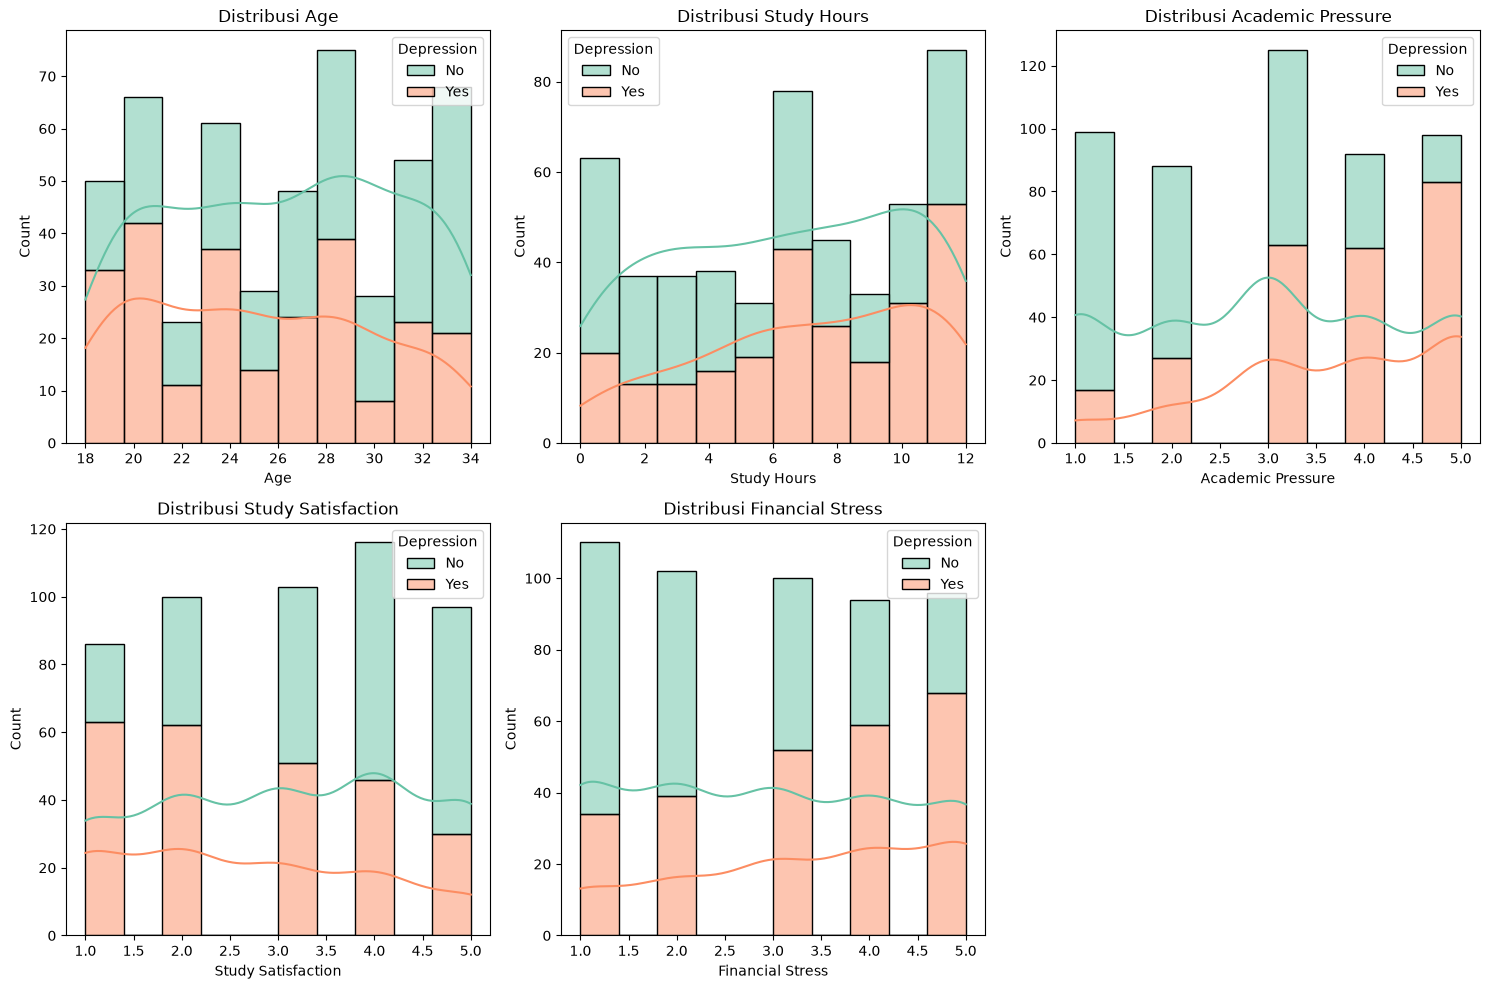

In [289]:
# EDA numerical col (Distribusi X terhadap targer)
print("\n--- Distribusi Fitur Numerik ---")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, kde=True, hue='Depression', ax=axes[i], palette='Set2', multiple="stack")
    axes[i].set_title(f'Distribusi {col}')

fig.delaxes(axes[-1]) 
plt.tight_layout()
plt.show()


--- Distribusi Fitur Kategorikal vs Target ---


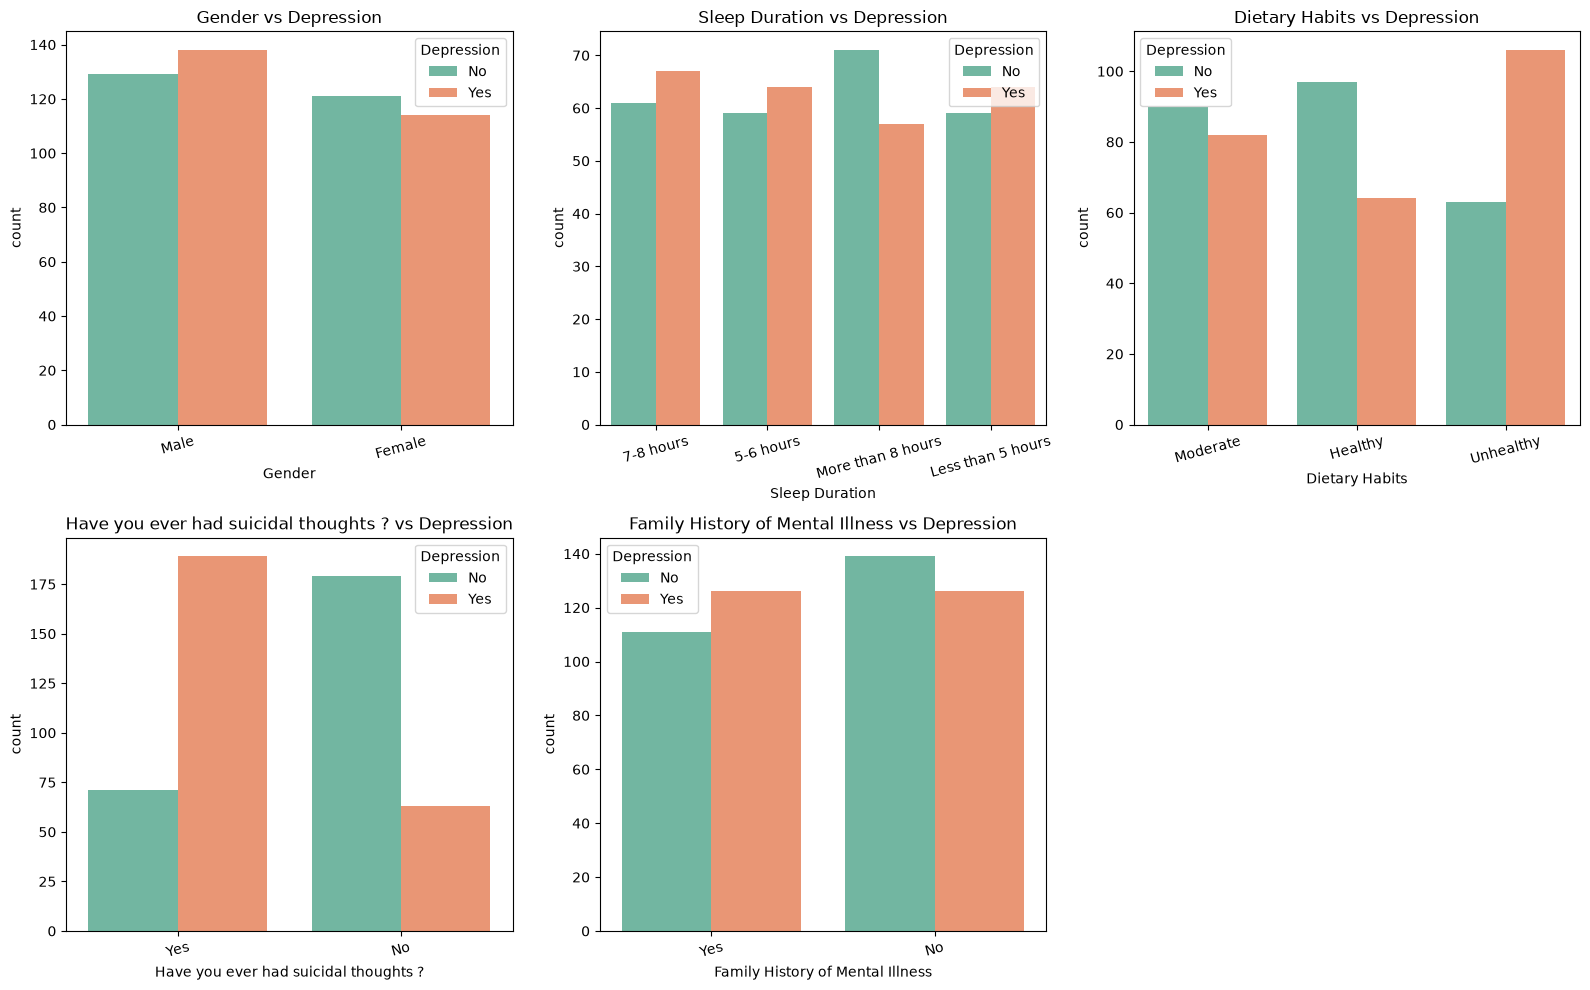

In [290]:
# EDA Fitur Kategorikal (Distribusi X terhadap Target)
print("\n--- Distribusi Fitur Kategorikal vs Target ---")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='Depression', ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Depression')
    axes[i].tick_params(axis='x', rotation=15) 

fig.delaxes(axes[-1]) # Menghapus subplot terakhir yang kosong
plt.tight_layout()
plt.show()

## 3. Data Pre-Processing

In [291]:
df_processed = df.copy()

In [292]:
# search categorical column
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()

# label endcoding
le = LabelEncoder()
for col in categorical_cols:
    df_processed[col] = le.fit_transform(df_processed[col])

/tmp/ipykernel_68670/2648387589.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()


In [293]:
# separating features (X) dan target (Y)
X = df_processed.drop('Depression', axis=1)
y = df_processed['Depression']

## 4. Splitting the Dataset into Training Set and Test Set

In [294]:
# using stratify=y to balance train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [295]:
# print the dimension X_train and X_test
print("Dimensi X_train:", X_train.shape)
print("Dimensi X_test:", X_test.shape)

Dimensi X_train: (401, 10)
Dimensi X_test: (101, 10)


## 5. Train and Evaluate the Model using Random Forest as Baseline Using All Feature

In [296]:
# initialize K-Fold (5)
# using stratified to ensure the ratio of depressed vs. non-depressed is balanced in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [297]:
# initialize the model
rf_baseline = RandomForestClassifier(n_estimators=75, random_state=42)

In [298]:
# determine the metrics you want to measure
scoring = ['accuracy', 'precision', 'recall', 'f1']

In [299]:
# do K-Fold Cross Validation
cv_results_base = cross_validate(rf_baseline, X, y, cv=cv, scoring=scoring)

In [300]:
# calculate the average from 5 results
acc_cv_base = cv_results_base['test_accuracy'].mean()
prec_cv_base = cv_results_base['test_precision'].mean()
rec_cv_base = cv_results_base['test_recall'].mean()
f1_cv_base = cv_results_base['test_f1'].mean()

print("--- RATA-RATA METRIK RF BASELINE (5-FOLD) ---")
print(f"Accuracy  : {acc_cv_base:.4f}")
print(f"Precision : {prec_cv_base:.4f}")
print(f"Recall    : {rec_cv_base:.4f}")
print(f"F1-Score  : {f1_cv_base:.4f}\n")

--- RATA-RATA METRIK RF BASELINE (5-FOLD) ---
Accuracy  : 0.8884
Precision : 0.8831
Recall    : 0.8967
F1-Score  : 0.8895



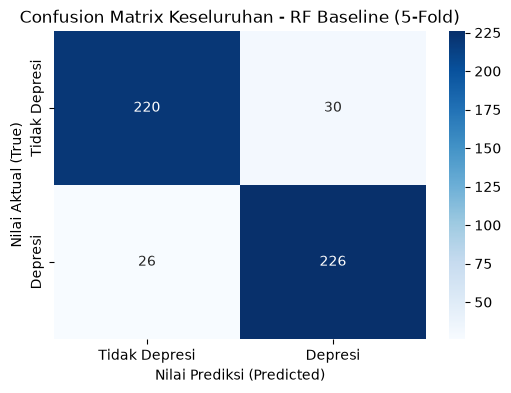

In [301]:
# creating a combined Confusion Matrix of all K-Fold
# cross_val_predict predict the data when it is the data's turn to be "Test Data"
pred_cv_base_all = cross_val_predict(rf_baseline, X, y, cv=cv)
cm_base = confusion_matrix(y, pred_cv_base_all)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Tidak Depresi', 'Depresi'], 
            yticklabels=['Tidak Depresi', 'Depresi'])
plt.title('Confusion Matrix Keseluruhan - RF Baseline (5-Fold)')
plt.ylabel('Nilai Aktual (True)')
plt.xlabel('Nilai Prediksi (Predicted)')
plt.show()

## 6. Feature Importance using SHAP

In [302]:
# training model for all data to analyzed by SHAP
rf_full = RandomForestClassifier(n_estimators=100, random_state=42)
rf_full.fit(X, y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [303]:
# SHAP explainer initialization
explainer = shap.TreeExplainer(rf_full)
shap_values = explainer.shap_values(X)

In [304]:
# handle the difference between SHAP version
if isinstance(shap_values, list):
    shap_values_target = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values_target = shap_values[:, :, 1]
else:
    shap_values_target = shap_values

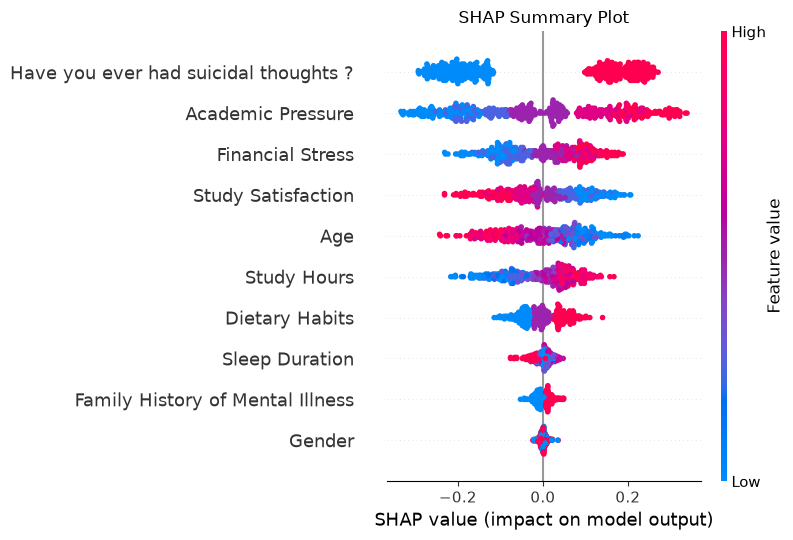

In [305]:
# SHAP plot summary 
plt.figure(figsize=(8, 5))
plt.title("SHAP Summary Plot")
shap.summary_plot(shap_values_target, X)

In [306]:
# count SHAP absolute average value to find top features
mean_shap_values = np.abs(shap_values_target).mean(axis=0)

In [307]:
# making a feature ranking DataFrame
shap_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'SHAP_Importance': mean_shap_values
}).sort_values(by='SHAP_Importance', ascending=False).reset_index(drop=True)

display(shap_importance_df.head(10))

,Feature,SHAP_Importance
0,Have you ever had suicidal thoughts ?,0.192539
1,Academic Pressure,0.158742
2,Financial Stress,0.081950
3,Study Satisfaction,0.078352
4,Age,0.075260
5,Study Hours,0.063639
6,Dietary Habits,0.037615
7,Sleep Duration,0.014733
8,Family History of Mental Illness,0.013164
9,Gender,0.005145


In [308]:
# taking top-5 best features
top_8_features = shap_importance_df['Feature'].head(8).tolist()
print("\nTop 5 Fitur Paling Penting menurut SHAP:")
for i, f in enumerate(top_8_features, 1):
    print(f"{i}. {f}")


Top 5 Fitur Paling Penting menurut SHAP:
1. Have you ever had suicidal thoughts ?
2. Academic Pressure
3. Financial Stress
4. Study Satisfaction
5. Age
6. Study Hours
7. Dietary Habits
8. Sleep Duration


## 7. Train and Evaluate the Model using Random Forest as Baseline Using Top Features

In [309]:
# filter X_train and X_test for using top 5 features
X_shap = X[top_8_features]

In [310]:
# running K-Fold Cross Validation for filtered data
cv_results_shap = cross_validate(rf_baseline, X_shap, y, cv=cv, scoring=scoring)

In [311]:
# count the average  value of 5 test result
acc_cv_shap = cv_results_shap['test_accuracy'].mean()
prec_cv_shap = cv_results_shap['test_precision'].mean()
rec_cv_shap = cv_results_shap['test_recall'].mean()
f1_cv_shap = cv_results_shap['test_f1'].mean()

print("--- RATA-RATA METRIK RF (TOP 5 SHAP) ---")
print(f"Accuracy  : {acc_cv_shap:.4f}")
print(f"Precision : {prec_cv_shap:.4f}")
print(f"Recall    : {rec_cv_shap:.4f}")
print(f"F1-Score  : {f1_cv_shap:.4f}\n")

--- RATA-RATA METRIK RF (TOP 5 SHAP) ---
Accuracy  : 0.9043
Precision : 0.8956
Recall    : 0.9166
F1-Score  : 0.9056



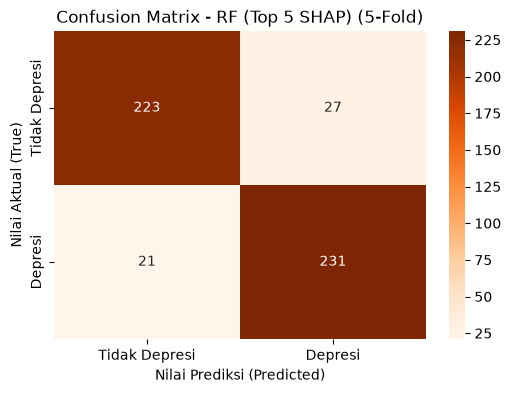

In [312]:
# Confusion Matrix combined top 5 SHAP
pred_cv_shap_all = cross_val_predict(rf_baseline, X_shap, y, cv=cv)
cm_shap = confusion_matrix(y, pred_cv_shap_all)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_shap, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Tidak Depresi', 'Depresi'], 
            yticklabels=['Tidak Depresi', 'Depresi'])
plt.title('Confusion Matrix - RF (Top 5 SHAP) (5-Fold)')
plt.ylabel('Nilai Aktual (True)')
plt.xlabel('Nilai Prediksi (Predicted)')
plt.show()

## 8. Comparison of Results

In [313]:
hasil_cv_df = pd.DataFrame({
    'Model': [
        'Random Forest (Baseline K-Fold)', 
        'Random Forest (Top 8 SHAP K-Fold)'
    ],
    'Mean Accuracy': [acc_cv_base, acc_cv_shap],
    'Mean Precision': [prec_cv_base, prec_cv_shap],
    'Mean Recall': [rec_cv_base, rec_cv_shap],
    'Mean F1-Score': [f1_cv_base, f1_cv_shap]
})

print("\nKESIMPULAN PERBANDINGAN MODEL (RATA-RATA K-FOLD):")
display(hasil_cv_df)


KESIMPULAN PERBANDINGAN MODEL (RATA-RATA K-FOLD):


,Model,Mean Accuracy,Mean Precision,Mean Recall,Mean F1-Score
0,Random Forest (Baseline K-Fold),0.888416,0.883051,0.896706,0.889509
1,Random Forest (Top 8 SHAP K-Fold),0.904337,0.895643,0.916627,0.905559


In [314]:
import joblib

# 1. Pastikan X_shap_8 sudah berisi 8 fitur teratas
# (Misalnya: X_shap_8 = X[['Fitur1', 'Fitur2', 'Fitur3', 'Fitur4', 'Fitur5', 'Fitur6', 'Fitur7', 'Fitur8']])

# 2. Latih model final menggunakan SELURUH data (bukan hasil split train/test)
rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_final.fit(X_shap, y)

# 3. Simpan model tersebut ke dalam file
joblib.dump(rf_final, 'model_depresi_8_fitur.pkl')
print("Model berhasil disimpan!")

Model berhasil disimpan!
